In [1]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [2]:
# State
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages] # list of messages with reducer 

In [3]:
llm = ChatOpenAI(model='gpt-4o-mini')

def chat_node(state: ChatState):
    message = state['messages']

    response = llm.invoke(message)

    return {'messages': [response]}

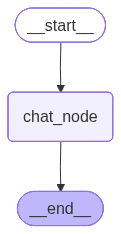

In [4]:
graph = StateGraph(ChatState)
checkpointer = MemorySaver()

graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatBot = graph.compile(checkpointer=checkpointer)
chatBot

In [8]:
thread_id = 1
while True:
    user_input = input('Type here: ')
    print('USER: ',user_input)

    if user_input.strip().lower() in ['exit', 'quit', 'bye']:
        print("AI: It's nice to talk with you. Bye!")
        break

    config = {'configurable': {'thread_id': thread_id}}
    initial_state = {'messages': [HumanMessage(content=user_input)]}

    # response = chatBot.invoke(initial_state, config=config)
    # print('AI: ', response['messages'][-1].content)

    # Streaming - give a generator
    # contain message chunk and metadata
    for message_chunk, metada in  chatBot.stream(
        initial_state, 
        config=config,
        stream_mode='messages'
    ):
        if message_chunk.content:
            print(message_chunk.content, end=" ", flush=True)


USER:  Hii, my name is semaphore
Hi  Semaphore !  It's  nice  to  meet  you .  How  can  I  assist  you  today ? USER:  Can you tell me the meaning of semaphore
Certainly !  The  term  ** " se maphore " **  can  have  different  meanings  based  on  context :

 1 .  ** In  Computing ** :  A  semaphore  is  a  synchronization  primitive  used  in  concurrent  programming .  It  is  a  variable  or  abstract  data  type  that  is  used  to  control  access  by  multiple  processes  to  common  resources  in  a  parallel  programming  environment .  Sem ap hores  help  prevent  race  conditions  by  managing  access  to  shared  variables .

 2 .  ** In  Communication ** :  A  semaphore  system  can  refer  to  a  method  of  signaling  using  visual  cues ,  such  as  flags  or  lights .  For  example ,  in  maritime  or  naval  contexts ,  sem ap hores  are  often  indicated  by  the  position  of  flags  or  a  mechanical  arm  to  communicate  messages .

 3 .  ** In  General  Use ** 

In [11]:
chatBot.get_state(config=config).values['messages']

[HumanMessage(content='hii', additional_kwargs={}, response_metadata={}, id='98c25a17-58cf-4dea-9516-ec556af54b30'),
 AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 9, 'total_tokens': 18, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f4ae844694', 'id': 'chatcmpl-D93fnfXFN3WZjzNqk8F8sWSGsNS2C', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c5ae4-60ab-7a83-ad43-2c1bdc240d99-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 9, 'total_tokens': 18, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, '